# Full Diffusion MRI Pipeline (Multi-level Degradation)

In [1]:
import torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.images = []

        print("Carregando dataset...")

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith(".mat"):
                    path = os.path.join(root, f)
                    data = loadmat(path)

                    if "x" not in data:
                        continue

                    x = data["x"]

                    for i in range(x.shape[2]):
                        img = x[:, :, i]

                        img = (img - img.min())/(img.max() - img.min() + 1e-8)

                        self.images.append(img.astype(np.float32))

        print("Total imagens:", len(self.images))

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx]).float()

        x = (x - x.mean())/(x.std() + 1e-8)

        x = x.unsqueeze(0).unsqueeze(0)   

        x = F.interpolate(x, size=(192,192), mode='bilinear', align_corners=False)

        x = x.squeeze(0)   

        return x

    def __len__(self):
        return len(self.images)

In [3]:
dataset_path = "/kaggle/input/datasets/semnickcharlie/brain-dataset1"
dataset = MRIDataset(dataset_path)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

Carregando dataset...
Total imagens: 4020


In [4]:
def fft2(x):
    return torch.fft.fft2(x)

def ifft2(k):
    return torch.fft.ifft2(k).real

def to_kspace(x):
    return torch.view_as_real(fft2(x))

def to_image(k):
    return ifft2(torch.view_as_complex(k))

In [5]:
def create_mask_t(shape, t, T, device):

    H, W = shape

    if torch.is_tensor(t):
        t = t.item()

    accel = 1 + (t / T) * 2.5

    mask = torch.zeros(H, W, device=device)

    num_spokes = max(4, int(H / accel))

    center_h = H // 2
    center_w = W // 2

    y, x = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing='ij'
    )

    y = y - center_h
    x = x - center_w

    for i in range(num_spokes):

        theta = torch.tensor(i * np.pi / num_spokes, device=device)

        line = torch.abs(x * torch.sin(theta) - y * torch.cos(theta))
        mask[line < 1.5] = 1

    dist = x**2 + y**2
    mask[dist <= 8**2] = 1

    return mask


In [6]:
def degrade_kspace(x, t, T):

    k = torch.fft.fft2(x)

    k = torch.fft.fftshift(k)

    mask = create_mask_t(k.shape[-2:], t, T, x.device)

    k = k * mask

    k = torch.fft.ifftshift(k)

    x_t = torch.fft.ifft2(k).real

    return x_t, torch.view_as_real(k), mask


Carregando dataset...
Total imagens: 4020


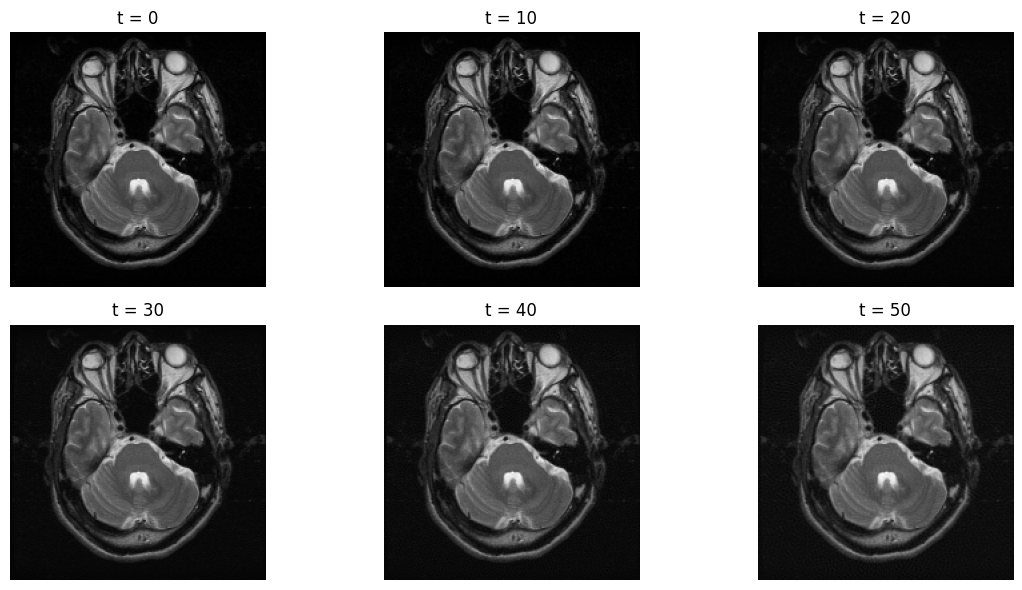

torch.Size([1, 192, 192])
(192, 192)


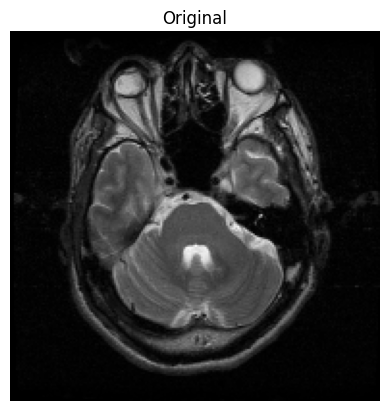

In [7]:
from matplotlib import pyplot as plt

dataset_path = "/kaggle/input/datasets/semnickcharlie/brain-dataset1"
dataset = MRIDataset(dataset_path)

img = dataset[700]
T = 50

plt.figure(figsize=(12, 6))

for idx, t_val in enumerate([0, 10, 20, 30, 40, 50]):
    x_t, _, _ = degrade_kspace(img, t_val, T)  
    
    plt.subplot(2, 3, idx + 1)
    plt.title(f"t = {t_val}")
    plt.imshow(x_t.squeeze().detach().cpu().numpy(), cmap="gray")  
    plt.axis("off")

plt.tight_layout()
plt.show()

print(img.shape)

x = img.squeeze().cpu().numpy()  
print(x.shape)

plt.imshow(x, cmap="gray")
plt.axis("off")
plt.title("Original")
plt.show()

In [8]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),
            nn.Linear(256, 512)
        )

        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = nn.Conv2d(256, 512, 3, padding=1)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)

        self.conv4 = nn.Conv2d(256+256, 256, 3, padding=1)
        self.conv5 = nn.Conv2d(128+64, 128, 3, padding=1)

        self.out = nn.Conv2d(128, 1, 1)

    def forward(self, x, t):

        t = t.view(-1,1)
        t_emb = self.time_mlp(t).view(-1,512,1,1)

        e1 = F.relu(self.conv1(x))
        e2 = F.relu(self.conv2(self.pool(e1)))
        e3 = F.relu(self.conv3(self.pool(e2)))

        b = F.relu(self.bottleneck(e3) + t_emb)

        d1 = self.up1(b)

        if d1.shape[-2:] != e3.shape[-2:]:
            d1 = F.interpolate(d1, size=e3.shape[-2:], mode='bilinear', align_corners=False)

        d1 = torch.cat([d1, e3], dim=1)
        d1 = F.relu(self.conv4(d1))

        d2 = self.up2(d1)

        if d2.shape[-2:] != e1.shape[-2:]:
            d2 = F.interpolate(d2, size=e1.shape[-2:], mode='bilinear', align_corners=False)

        d2 = torch.cat([d2, e1], dim=1)
        d2 = F.relu(self.conv5(d2))

        return self.out(d2)

In [9]:
def data_consistency(x, k_obs, mask):

    k = fft2(x)
    mask = mask.float()

    k = mask * k_obs + (1 - mask) * k

    return ifft2(k)

In [10]:
model = UNet().to(device)

In [11]:
def ssim_loss(pred, target):

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    
    mu_x = F.avg_pool2d(pred, 11, 1, 5)
    mu_y = F.avg_pool2d(target, 11, 1, 5)
    
    sigma_x = F.avg_pool2d(pred**2, 11, 1, 5) - mu_x**2
    sigma_y = F.avg_pool2d(target**2, 11, 1, 5) - mu_y**2
    sigma_xy = F.avg_pool2d(pred*target, 11, 1, 5) - mu_x*mu_y

    ssim = ((2*mu_x*mu_y + C1)*(2*sigma_xy+C2)) / \
           ((mu_x**2+mu_y**2+C1)*(sigma_x+sigma_y+C2))

    return 1 - ssim.mean()

In [12]:
def train(model, loader, epochs=20, T_max=20, max_batches=400):

    opt = torch.optim.Adam(model.parameters(), 5e-5)

    for epoch in range(epochs):
        print("\nEpoch", epoch)

        total_loss = 0
        count = 0

        for i, x in enumerate(loader):

            if i >= max_batches:
                break

            x = x.to(device)

            t = torch.randint(1, T_max, (x.shape[0],), device=device)
            t_norm = t.float() / T_max

            x_t_list = []

            for b in range(x.shape[0]):
                x_t, _, _ = degrade_kspace(x[b], t[b], T_max)
                x_t_list.append(x_t)

            x_t = torch.stack(x_t_list)

            pred = model(x_t, t_norm)

            pred_img = x_t.squeeze(1) - pred.squeeze(1)
            x_img = x.squeeze(1)

            loss = torch.abs(pred_img - x_img).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            count += 1

        print("Loss:", total_loss / count)

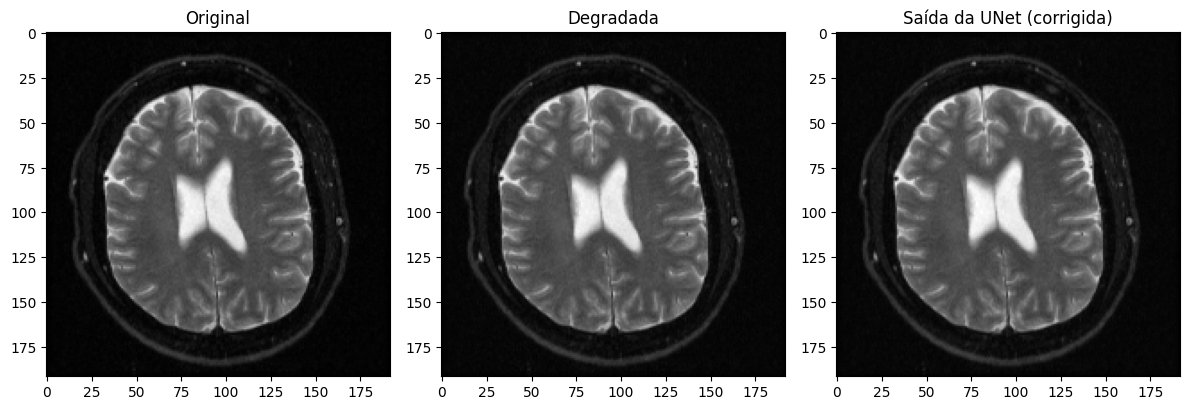

In [13]:
model.eval()

x = dataset[10].unsqueeze(0).to(device)

t_val = 10
T_max = 20

t = torch.tensor([t_val], device=device).float() / T_max

with torch.no_grad():
    
    x_t, _, _ = degrade_kspace(x, t_val, T_max)
    
    residual = model(x_t, t)
    
    pred_img = x_t.squeeze(1) - residual.squeeze(1)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(x[0,0].cpu(), cmap="gray")
plt.title("Original")

plt.subplot(132)
plt.imshow(x_t[0,0].cpu(), cmap="gray")
plt.title("Degradada")

plt.subplot(133)
plt.imshow(pred_img[0].cpu(), cmap="gray")
plt.title("Saída da UNet (corrigida)")

plt.tight_layout()
plt.show()

In [14]:
def reconstruct(model, x, T_max=20):

    x = x.to(device)

    x_t, k_obs_real, mask_full = degrade_kspace(x, T_max, T_max)
    k_obs = torch.view_as_complex(k_obs_real)

    x_t = x_t.unsqueeze(0).unsqueeze(0)

    for t_step in reversed(range(1, T_max)):

        t_tensor = torch.tensor([t_step / T_max], device=device).float()

        x_t = x_t.squeeze(0)

        residual = model(x_t, t_tensor)

        x_hat = x_t.squeeze(1) - residual.squeeze(1)

        k_hat = torch.fft.fftshift(torch.fft.fft2(x_hat))
        k_obs_shifted = torch.fft.fftshift(k_obs)

        k_new = mask_full * k_obs_shifted + (1 - mask_full) * k_hat

        k_new = torch.fft.ifftshift(k_new)
        x_t = torch.fft.ifft2(k_new).real

        x_t = x_t.unsqueeze(0).unsqueeze(0)

    return x_t


Epoch 0
Loss: 0.018646909496746956

Epoch 1
Loss: 0.016657272665761412

Epoch 2
Loss: 0.016761721725924873

Epoch 3
Loss: 0.015073171514086426

Epoch 4
Loss: 0.01533164771622978

Epoch 5
Loss: 0.014503712475998328

Epoch 6
Loss: 0.01490046999824699

Epoch 7
Loss: 0.013918281386722811

Epoch 8
Loss: 0.014437406270299108

Epoch 9
Loss: 0.014414752015436533

Epoch 10
Loss: 0.013855403675697743

Epoch 11
Loss: 0.014416348558152095

Epoch 12
Loss: 0.013918784908310045

Epoch 13
Loss: 0.014354884599451907

Epoch 14
Loss: 0.013271895525394938


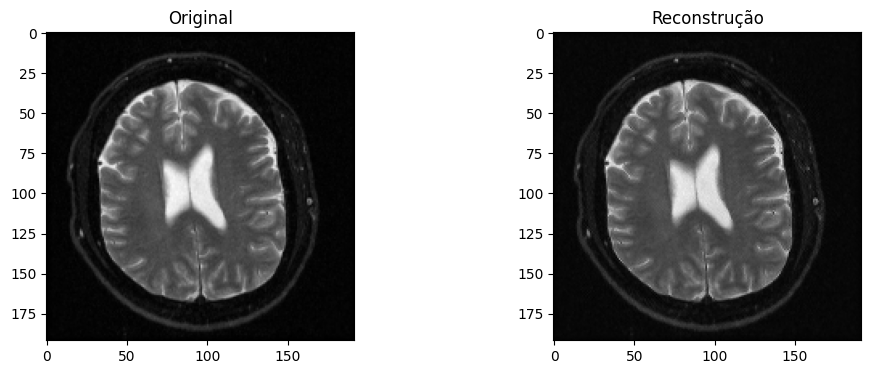

In [15]:
train(model, loader, epochs=15)

x = dataset[10]
recon = reconstruct(model, x)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(x.squeeze().numpy(), cmap='gray')

plt.subplot(1,2,2)
plt.title("Reconstrução")
plt.imshow(recon.squeeze().detach().cpu().numpy(), cmap='gray')

plt.show()